In [1]:
import re
import ftfy
import shap
import torch
import unicodedata
import numpy as np
import matplotlib.pyplot as plt

import torch.nn.functional as F

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

In [2]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device :", device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

Device : cuda
NVIDIA GeForce RTX 3060 Ti


In [3]:
MODEL_PATH = "../model/indobert_optuna_best"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_PATH
)

model.to(device)
model.eval()

print("Model berhasil dimuat.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model berhasil dimuat.


In [4]:
# =====================================================
# PREPROCESSING
# =====================================================

mapping = {

    "А":"A","В":"B","Е":"E","К":"K","М":"M","Н":"H",
    "О":"O","Р":"P","С":"C","Т":"T","Х":"X","У":"Y",

    "а":"a","е":"e","о":"o","р":"p","с":"c",
    "х":"x","у":"y","к":"k","м":"m","н":"h",

    "Α":"A","Β":"B","Ε":"E","Η":"H",
    "Ι":"I","Κ":"K","Μ":"M","Ν":"N",
    "Ο":"O","Ρ":"P","Τ":"T","Χ":"X"

}

TRANSLATE_TABLE = str.maketrans(mapping)

HTML_RE = re.compile(r"<.*?>")
URL_RE = re.compile(r"http\S+")
WWW_RE = re.compile(r"www\S+")
MENTION_RE = re.compile(r"@\w+")
EMOJI_RE = re.compile(r"[\U00010000-\U0010ffff]", flags=re.UNICODE)
SPECIAL_RE = re.compile(r"[^A-Za-z0-9\s]")
SPACE_RE = re.compile(r"\s+")


def preprocess(text):

    text = str(text)

    # Unicode Normalize
    text = ftfy.fix_text(text)
    text = unicodedata.normalize("NFKC", text)
    text = text.translate(TRANSLATE_TABLE)

    # Cleaning
    text = HTML_RE.sub(" ", text)
    text = URL_RE.sub(" ", text)
    text = WWW_RE.sub(" ", text)
    text = MENTION_RE.sub(" ", text)
    text = EMOJI_RE.sub(" ", text)
    text = SPECIAL_RE.sub(" ", text)

    # Case Folding
    text = text.lower()

    # Hapus spasi berlebih
    text = SPACE_RE.sub(" ", text)

    return text.strip()

In [5]:
import torch.nn.functional as F

MAX_LENGTH = 128

def predict_proba(texts):

    texts = [preprocess(t) for t in texts]

    inputs = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt"
    )

    inputs = {
        k: v.to(device)
        for k, v in inputs.items()
    }

    with torch.no_grad():

        outputs = model(**inputs)

        probs = F.softmax(outputs.logits, dim=1)

    return probs.cpu().numpy()

In [6]:
explainer = shap.Explainer(
    predict_proba,
    tokenizer
)

print(explainer)

shap.explainers.PartitionExplainer()


In [9]:
text = "bonus new member slot gacor terpercaya"

probs = predict_proba([text])

print("Teks:", text)
print("Probabilitas:")
print("Bukan Promosi Judi Online :", probs[0][0])
print("Promosi Judi Online       :", probs[0][1])
print("Prediksi kelas            :", np.argmax(probs[0]))

Teks: bonus new member slot gacor terpercaya
Probabilitas:
Bukan Promosi Judi Online : 0.0037127803
Promosi Judi Online       : 0.9962872
Prediksi kelas            : 1


In [10]:
shap_values = explainer([text])

print(shap_values.shape)

(1, 8, 2)


In [11]:
tokens = shap_values.data[0]

print("Token dan SHAP value untuk kelas Promosi Judi Online:")
for token, value in zip(tokens, shap_values.values[0, :, 1]):
    print(f"{token:15} {value:.6f}")

Token dan SHAP value untuk kelas Promosi Judi Online:
                0.000000
bonus           0.149050
new             -0.009268
member          0.146716
slot            0.257252
gacor           0.310679
terpercaya      0.141018
                -0.000000


In [12]:
shap.plots.text(shap_values[0])

In [13]:
print("Output names:")
print(shap_values.output_names)

print("\nBase values:")
print(shap_values.base_values)

print("\nSHAP values class 0:")
print(shap_values.values[0, :, 0])

print("\nSHAP values class 1:")
print(shap_values.values[0, :, 1])

Output names:
['Output 0', 'Output 1']

Base values:
[[9.99159217e-01 8.40806519e-04]]

SHAP values class 0:
[-2.23517418e-08 -1.49050312e-01  9.26801463e-03 -1.46715538e-01
 -2.57251842e-01 -3.10679023e-01 -1.41017737e-01  2.23517418e-08]

SHAP values class 1:
[ 2.60770321e-08  1.49050266e-01 -9.26802800e-03  1.46715578e-01
  2.57251837e-01  3.10679018e-01  1.41017749e-01 -2.60770321e-08]


In [14]:
shap.plots.text(shap_values[0, :, 1])

In [7]:
text = "bonus new member slot gacor terpercaya"

print(text)

bonus new member slot gacor terpercaya


In [8]:
shap_values = explainer([text])

In [9]:
print(shap_values.shape)

(1, 8, 2)


In [10]:
shap.plots.text(shap_values[0])

In [16]:
import pandas as pd

df = pd.read_csv("../dataset/dataset.csv")

print(df.columns)
print(df.shape)

Index(['label', 'author', 'comment', 'id', 'channel', 'title'], dtype='str')
(20807, 6)


In [19]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

print("Train :", len(train_df))
print("Valid :", len(valid_df))
print("Test  :", len(test_df))

Train : 16645
Valid : 2081
Test  : 2081


In [20]:
import pandas as pd

# Ambil 100 teks dari data test
global_texts = test_df["hasil_preprocessing"].sample(
    n=100,
    random_state=42
).tolist()

print("Jumlah teks:", len(global_texts))

KeyError: 'hasil_preprocessing'

In [11]:
import torch.nn.functional as F

inputs = tokenizer(
    preprocess(text),
    return_tensors="pt",
    truncation=True,
    padding=True,
    max_length=128
)

inputs = {
    k: v.to(device)
    for k, v in inputs.items()
}

with torch.no_grad():

    outputs = model(**inputs)

    probs = F.softmax(outputs.logits, dim=1)

pred = torch.argmax(probs).item()

labels = {
    0: "Bukan Judi Online",
    1: "Judi Online"
}

print("Prediksi :", labels[pred])
print("Probabilitas :", probs.cpu().numpy())

Prediksi : Judi Online
Probabilitas : [[0.01844371 0.9815563 ]]


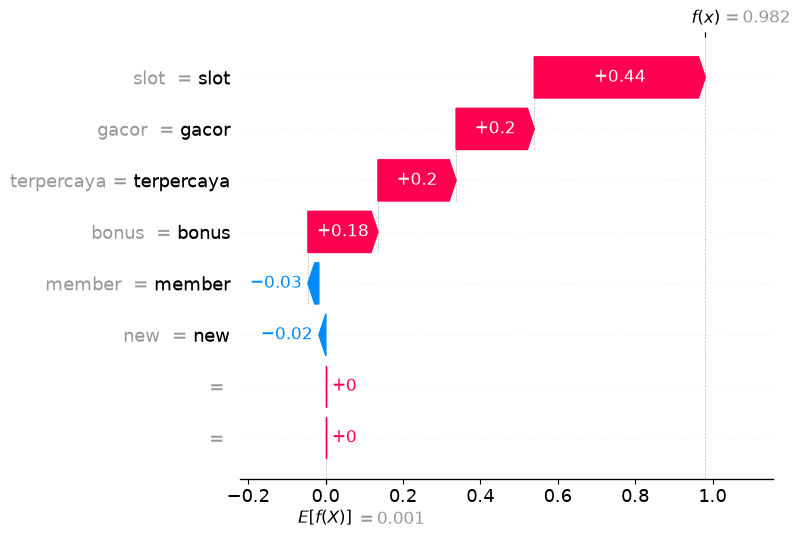

Waterfall plot berhasil disimpan.


In [12]:
plt.figure(figsize=(8, 6))

shap.plots.waterfall(
    shap_values[0, :, 1],
    show=False
)

plt.tight_layout()
plt.savefig(
    "../output/shap_waterfall_plot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("Waterfall plot berhasil disimpan.")

<Figure size 1400x300 with 0 Axes>

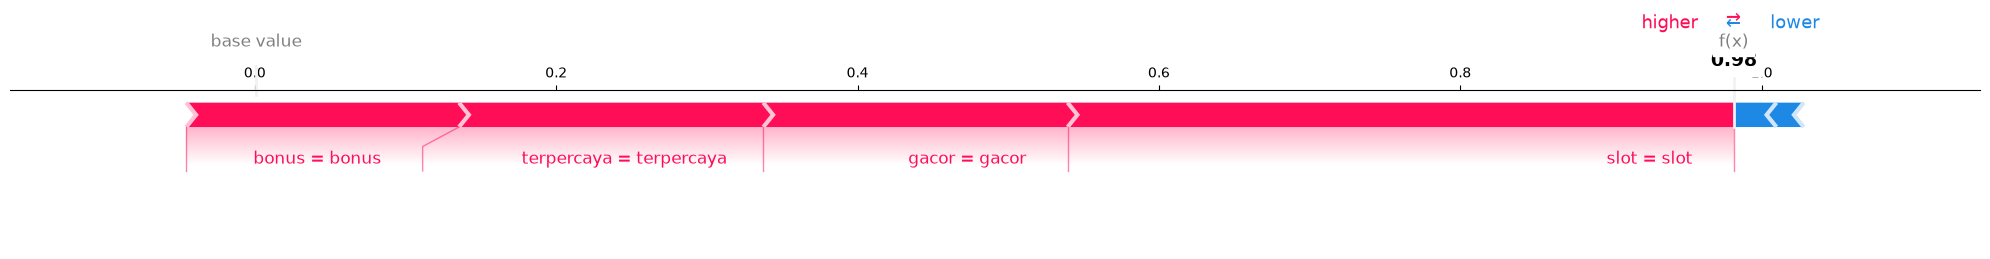

Force plot berhasil disimpan (PNG & HTML).


In [13]:
# =====================================================
# FORCE PLOT
# =====================================================

plt.figure(figsize=(14, 3))

shap.plots.force(
    shap_values[0, :, 1],
    matplotlib=True,
    show=False
)

plt.tight_layout()
plt.savefig(
    "../output/shap_force_plot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

force_vis = shap.plots.force(
    shap_values[0, :, 1],
    matplotlib=False,
    show=False
)

shap.save_html(
    "../output/shap_force_plot.html",
    force_vis
)

print("Force plot berhasil disimpan (PNG & HTML).")

In [14]:
import pandas as pd

from sklearn.model_selection import train_test_split

DATASET_PATH = "../output/dataset_preprocessing.csv"

df = pd.read_csv(DATASET_PATH)

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

print("Train :", len(train_df))
print("Valid :", len(valid_df))
print("Test  :", len(test_df))

Train : 16645
Valid : 2081
Test  : 2081


In [15]:
texts = test_df["hasil_preprocessing"].sample(
    n=100,
    random_state=42
).tolist()

values = explainer(texts)

PartitionExplainer explainer: 101it [00:47,  1.66it/s]                         


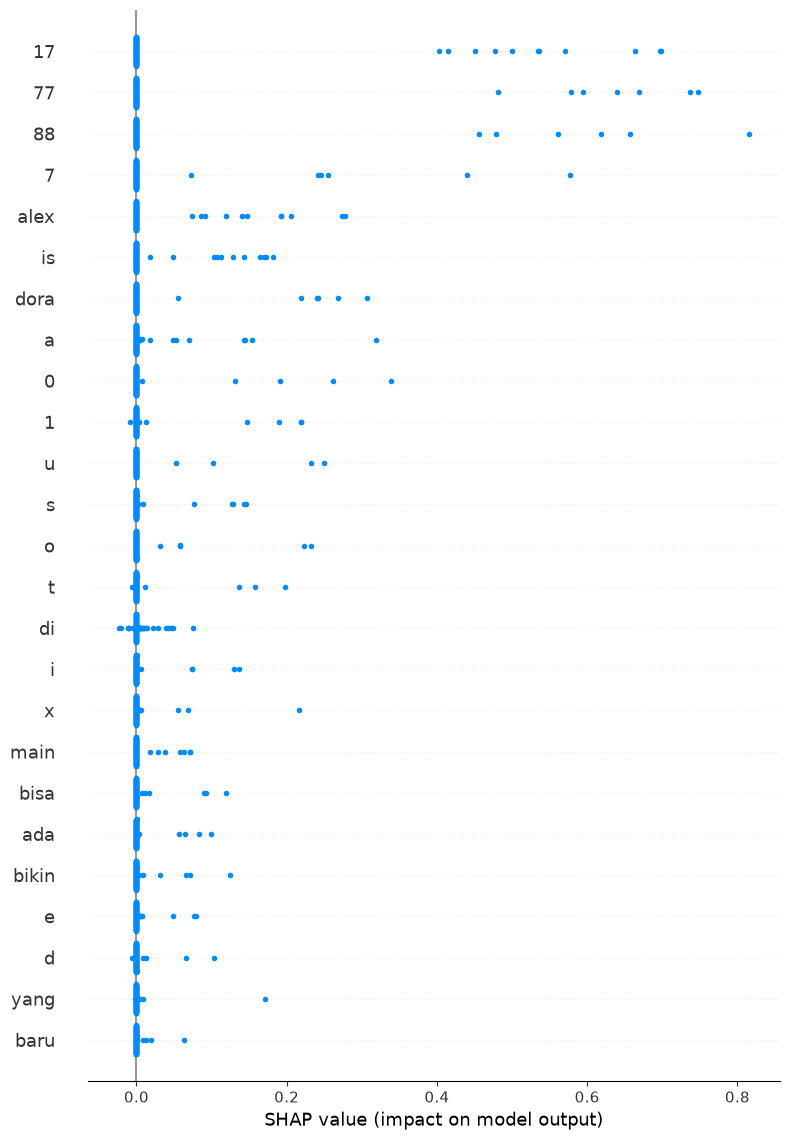

Summary plot berhasil disimpan.


In [16]:
# =====================================================
# SUMMARY PLOT (100 sampel uji, kelas Judi Online)
# =====================================================

import numpy as np

from collections import Counter

token_count = Counter()

for sample in values:
    token_count.update(
        str(token).strip()
        for token in sample.data
        if str(token).strip()
    )

top_tokens = [
    token
    for token, _ in token_count.most_common(40)
]

token_index = {
    token: i
    for i, token in enumerate(top_tokens)
}

shap_matrix = np.zeros(
    (len(values), len(top_tokens))
)

for i, sample in enumerate(values):

    tokens = [
        str(token).strip()
        for token in sample.data
    ]

    scores = sample.values[:, 1]

    for token, score in zip(tokens, scores):

        if token in token_index:

            shap_matrix[i, token_index[token]] += score

plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_matrix,
    feature_names=top_tokens,
    max_display=25,
    show=False
)

plt.tight_layout()
plt.savefig(
    "../output/shap_summary_plot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("Summary plot berhasil disimpan.")

In [16]:
from collections import defaultdict
import pandas as pd

token_scores = defaultdict(list)

for sample in values:

    tokens = sample.data

    shap_scores = sample.values[:, 1]

    for token, score in zip(tokens, shap_scores):

        token = token.strip()

        if token == "":
            continue

        token_scores[token].append(abs(score))

In [17]:
importance = []

for token, scores in token_scores.items():

    importance.append({

        "Token": token,

        "Mean_SHAP": sum(scores) / len(scores),

        "Frequency": len(scores)

    })

importance = pd.DataFrame(importance)

importance = importance.sort_values(

    by="Mean_SHAP",

    ascending=False

)

importance.head(20)

,Token,Mean_SHAP,Frequency
356,777,0.678175,3
30,77,0.635526,7
241,88,0.597585,6
7,agust,0.590255,3
59,17,0.540308,11
102,99,0.433652,2
398,69,0.429202,1
724,xy,0.336593,1
192,4,0.320537,4
8,oto,0.315165,3


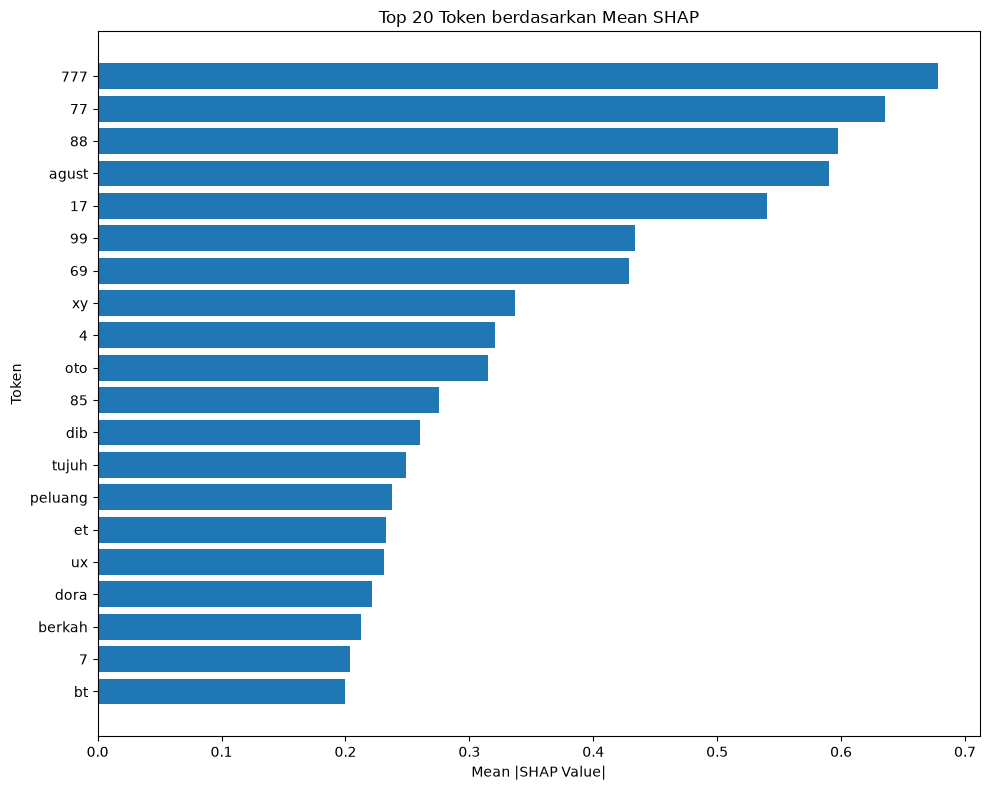

In [18]:
import matplotlib.pyplot as plt

top20 = importance.head(20)

plt.figure(figsize=(10,8))

plt.barh(

    top20["Token"],

    top20["Mean_SHAP"]

)

plt.gca().invert_yaxis()

plt.xlabel("Mean |SHAP Value|")

plt.ylabel("Token")

plt.title("Top 20 Token berdasarkan Mean SHAP")

plt.tight_layout()

plt.savefig(

    "../output/shap_global_importance.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

In [19]:
importance.to_csv(

    "../output/shap_global_importance.csv",

    index=False,

    encoding="utf-8-sig"

)

print("Berhasil disimpan.")

Berhasil disimpan.


In [20]:
shap.plots.text(values[0])

In [21]:
shap.plots.text(values[1])

In [22]:
from collections import defaultdict
import numpy as np
import pandas as pd

token_scores = defaultdict(list)

for sample in values:

    tokens = [
        str(token).strip()
        for token in sample.data
    ]

    scores = sample.values[:, 1]

    # Gabungkan token yang sama dalam satu komentar
    sample_scores = defaultdict(float)

    for token, score in zip(tokens, scores):

        if token == "":
            continue

        sample_scores[token] += float(score)

    # Simpan kontribusi token pada level komentar
    for token, score in sample_scores.items():

        token_scores[token].append(score)

In [23]:
global_rows = []

for token, scores in token_scores.items():

    scores = np.array(scores)

    global_rows.append({
        "token": token,
        "Mean_Abs_SHAP": np.mean(np.abs(scores)),
        "Mean_SHAP": np.mean(scores),
        "Frequency": len(scores)
    })

global_df = pd.DataFrame(global_rows)

global_df = global_df.sort_values(
    "Mean_Abs_SHAP",
    ascending=False
)

print(global_df.head(20))

       token  Mean_Abs_SHAP  Mean_SHAP  Frequency
690    tujuh       0.745757   0.745757          1
356      777       0.678175   0.678175          3
30        77       0.635526   0.635526          7
241       88       0.597585   0.597585          6
7      agust       0.590255   0.590255          3
59        17       0.540308   0.540308         11
102       99       0.433652   0.433652          2
398       69       0.429202   0.429202          1
724       xy       0.336593   0.336593          1
192        4       0.320537   0.320537          4
8        oto       0.315165   0.315165          3
566        7       0.305081   0.305081          6
21        85       0.275207   0.275207          1
367      dib       0.260370   0.260370          1
348  peluang       0.237873   0.237873          1
368       et       0.232548   0.232548          1
190       ux       0.231155   0.231155          1
29      dora       0.221731   0.221731          6
101   berkah       0.212696   0.209672          2


In [28]:
shap_texts = (
    test_df["hasil_preprocessing"]
    .dropna()
    .sample(n=500, random_state=42)
    .tolist()
)

values = explainer(shap_texts)

print("Jumlah teks untuk SHAP global:", len(values))

PartitionExplainer explainer: 501it [04:02,  1.99it/s]                         

Jumlah teks untuk SHAP global: 500


In [29]:
from collections import defaultdict
import numpy as np
import pandas as pd

# Menyimpan kontribusi token per komentar
token_scores_per_sample = []

for sample in values:

    tokens = [
        str(token).strip()
        for token in sample.data
    ]

    scores = sample.values[:, 1]

    sample_scores = defaultdict(float)

    for token, score in zip(tokens, scores):

        if token == "":
            continue

        sample_scores[token] += float(score)

    token_scores_per_sample.append(sample_scores)

print("Jumlah sampel:", len(token_scores_per_sample))

Jumlah sampel: 500


In [30]:
all_tokens = sorted({
    token
    for sample_scores in token_scores_per_sample
    for token in sample_scores.keys()
})

token_index = {
    token: i
    for i, token in enumerate(all_tokens)
}

shap_matrix = np.zeros(
    (len(token_scores_per_sample), len(all_tokens))
)

for i, sample_scores in enumerate(token_scores_per_sample):

    for token, score in sample_scores.items():

        shap_matrix[
            i,
            token_index[token]
        ] = score

print("Shape SHAP matrix:", shap_matrix.shape)

Shape SHAP matrix: (500, 2361)


In [32]:
global_df = pd.DataFrame({
    "token": all_tokens,
    "Mean_Abs_SHAP": np.mean(
        np.abs(shap_matrix),
        axis=0
    ),
    "Mean_SHAP": np.mean(
        shap_matrix,
        axis=0
    ),
    "Frequency": np.sum(
        shap_matrix != 0,
        axis=0
    )
})

global_df = global_df.sort_values(
    "Mean_Abs_SHAP",
    ascending=False
)

print(global_df.head(20).to_string(index=False))

 token  Mean_Abs_SHAP  Mean_SHAP  Frequency
    88       0.094910   0.094910         71
    17       0.051579   0.051579         48
    77       0.020196   0.020196         18
  alex       0.016102   0.016102         45
    99       0.015634   0.015634         18
     4       0.013399   0.013394         22
     7       0.012241   0.012229         21
    is       0.012108   0.012108         46
   777       0.011974   0.011974          8
junior       0.011674   0.011674         28
     8       0.009173   0.009173         15
     o       0.008901   0.008901         43
   bet       0.008555   0.008490         18
     a       0.008438   0.008427         54
     0       0.005812   0.005812         17
     s       0.005432   0.005418         39
     i       0.005186   0.005186         34
    69       0.005006   0.005006          7
    55       0.004988   0.004988          5
 gacor       0.004658   0.004658          5


In [33]:
global_df.to_csv(
    "../output/shap_global_importance.csv",
    index=False
)

In [34]:
top_tokens = global_df.head(25)["token"].tolist()

top_indices = [
    token_index[token]
    for token in top_tokens
]

top_shap_matrix = shap_matrix[:, top_indices]

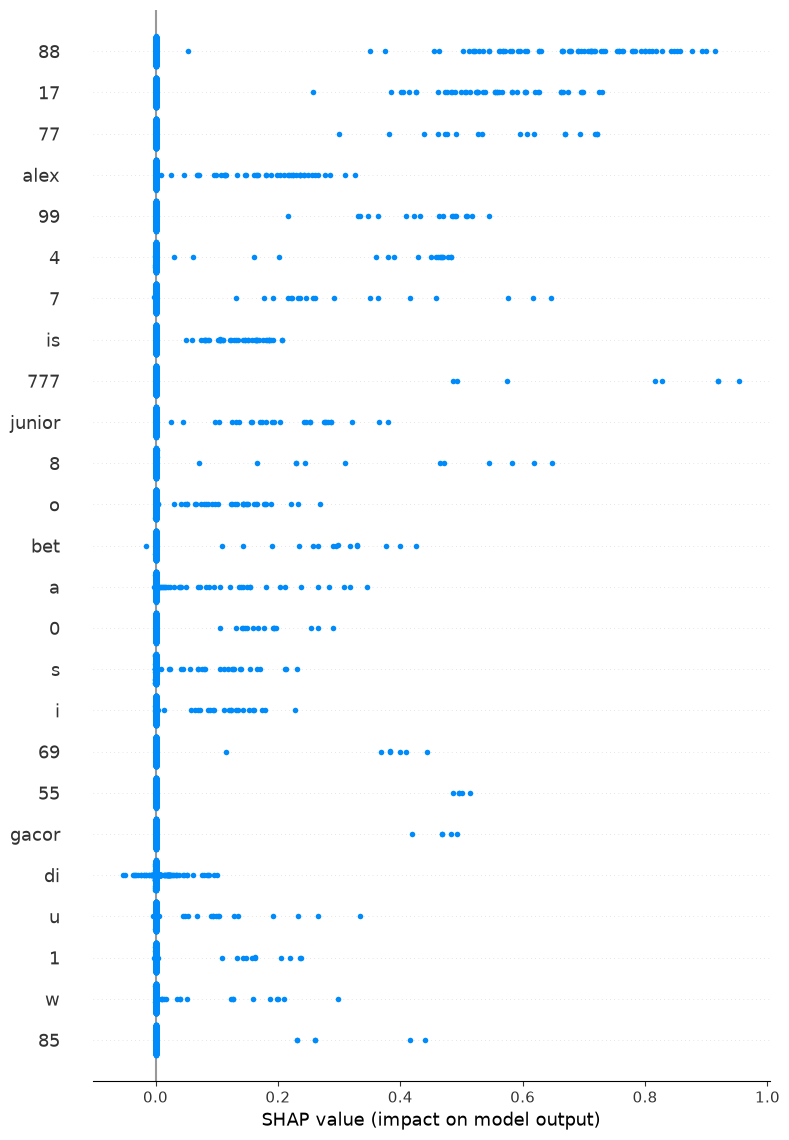

In [35]:
import matplotlib.pyplot as plt
import shap

plt.figure(figsize=(10, 8))

shap.summary_plot(
    top_shap_matrix,
    feature_names=top_tokens,
    max_display=25,
    show=False
)

plt.tight_layout()

plt.savefig(
    "../output/shap_summary_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

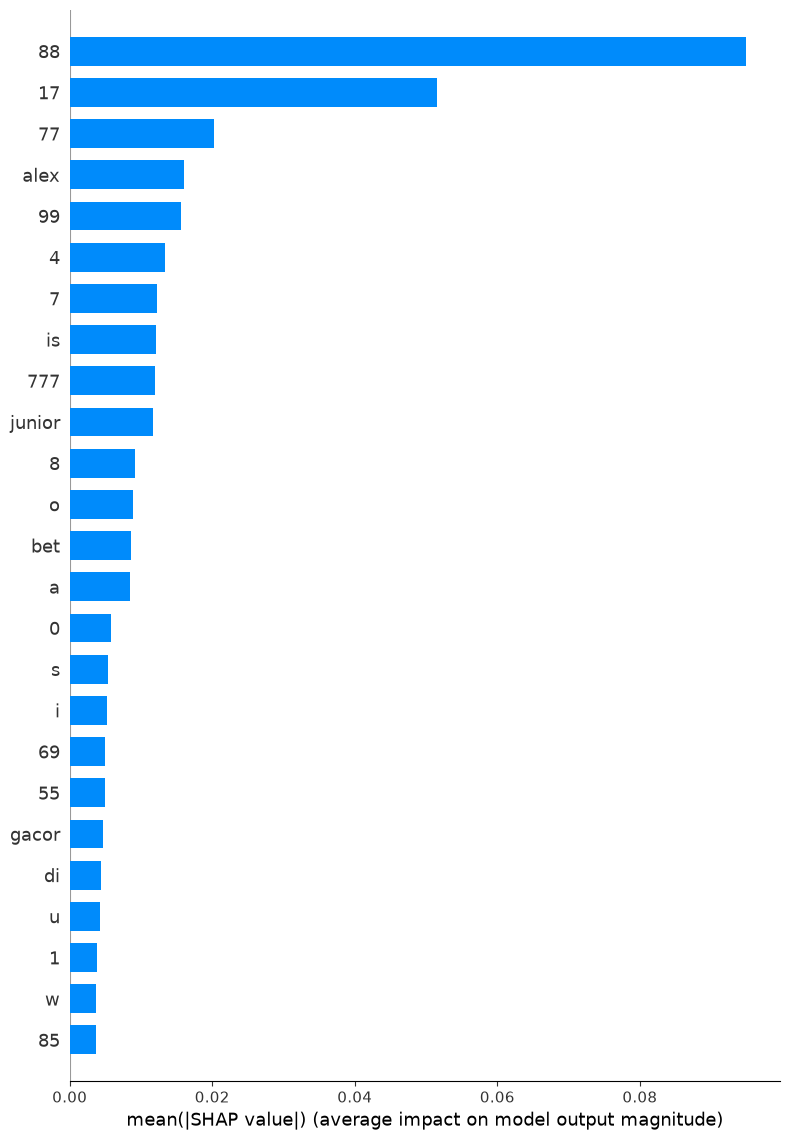

In [38]:
plt.figure(figsize=(10, 8))

shap.summary_plot(
    top_shap_matrix,
    feature_names=top_tokens,
    plot_type="bar",
    max_display=25,
    show=False
)

plt.tight_layout()

plt.savefig(
    "../output/shap_summary_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [36]:
test_tokens = tokenizer.tokenize(
    "bonus new member slot gacor terpercaya 88 777"
)

print(test_tokens)

['bonus', 'new', 'member', 'slot', 'gacor', 'terpercaya', '88', '77', '##7']


In [37]:
for token in test_tokens:
    print(token)

bonus
new
member
slot
gacor
terpercaya
88
77
##7


In [24]:
top_tokens = global_df.head(25)["token"].tolist()

In [39]:
import pandas as pd
import numpy as np

# Ambil teks dan label aktual dari data uji
candidates = test_df[
    ["hasil_preprocessing", "label"]
].dropna().copy()

# Prediksi probabilitas
probs = predict_proba(
    candidates["hasil_preprocessing"].tolist()
)

# Prediksi model
candidates["predicted_label"] = np.argmax(probs, axis=1)

# Confidence prediksi
candidates["confidence"] = np.max(probs, axis=1)

# Ambil hanya:
# label aktual = 0
# prediksi = 0
# teks cukup panjang
non_promosi = candidates[
    (candidates["label"] == 0) &
    (candidates["predicted_label"] == 0) &
    (candidates["hasil_preprocessing"].str.len() >= 20)
].copy()

# Urutkan dari confidence tertinggi
non_promosi = non_promosi.sort_values(
    "confidence",
    ascending=False
)

print(
    non_promosi[
        ["hasil_preprocessing", "label", "predicted_label", "confidence"]
    ].head(10).to_string(index=False)
)

                                                                                                                                                                                                                                                                        hasil_preprocessing  label  predicted_label  confidence
                                                                                                                                                                                                                       harus nya luhut jadi saksi jokowi biar jelas jokowi ijazah palsu nya      0                0    0.999637
                                                                                                                                                                                                        kejar terus demi kebenara jokowi sudah menghianat bsngsa bahkan ada yg di korbankan      0                0    0.999630
         rakyat sudah tidak percaya lagi

In [40]:
selected_text = " ijazah jokowi kayakny palsu cuma orang gk waras aja yg prcaya klw itu asli "

In [41]:
selected_value = explainer([selected_text])

tokens = [
    str(token).strip()
    for token in selected_value[0].data
]

scores = selected_value[0].values[:, 1]

for token, score in zip(tokens, scores):
    if token != "":
        print(f"{token:20s} {score:+.6f}")

ijazah               -0.000047
jokowi               -0.000226
kayak                +0.000060
ny                   -0.000087
palsu                -0.000098
cuma                 +0.000112
orang                +0.000089
gk                   -0.000158
waras                +0.000035
aja                  +0.000034
yg                   -0.000020
pr                   +0.000061
caya                 -0.000023
klw                  -0.000041
itu                  -0.000064
asli                 -0.000020


In [42]:
proba = predict_proba([selected_text])[0]

label = int(np.argmax(proba))
confidence = float(proba[label])

print("Teks       :", selected_text)
print("Label      :", label)
print("Prediction :", "Promosi Judi Online" if label == 1 else "Bukan Promosi Judi Online")
print("Confidence :", confidence)

Teks       :  ijazah jokowi kayakny palsu cuma orang gk waras aja yg prcaya klw itu asli 
Label      : 0
Prediction : Bukan Promosi Judi Online
Confidence : 0.9996159076690674


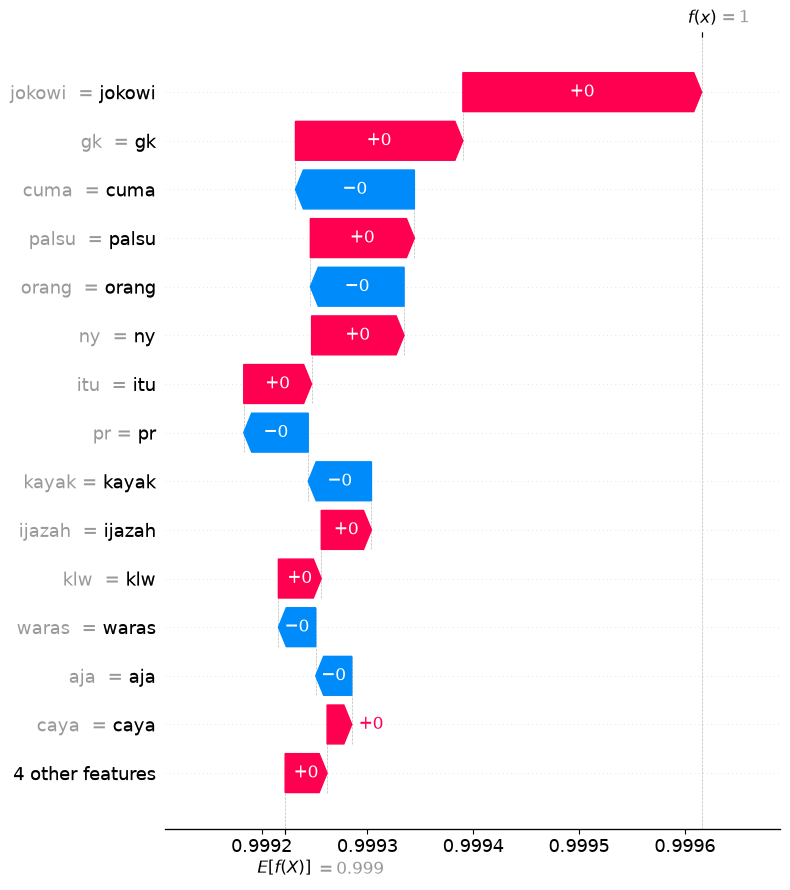

In [43]:
shap.plots.waterfall(
    selected_value[0, :, 0],
    max_display=15,
    show=False
)

plt.tight_layout()
plt.savefig(
    "../output/shap_waterfall_non_promosi.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

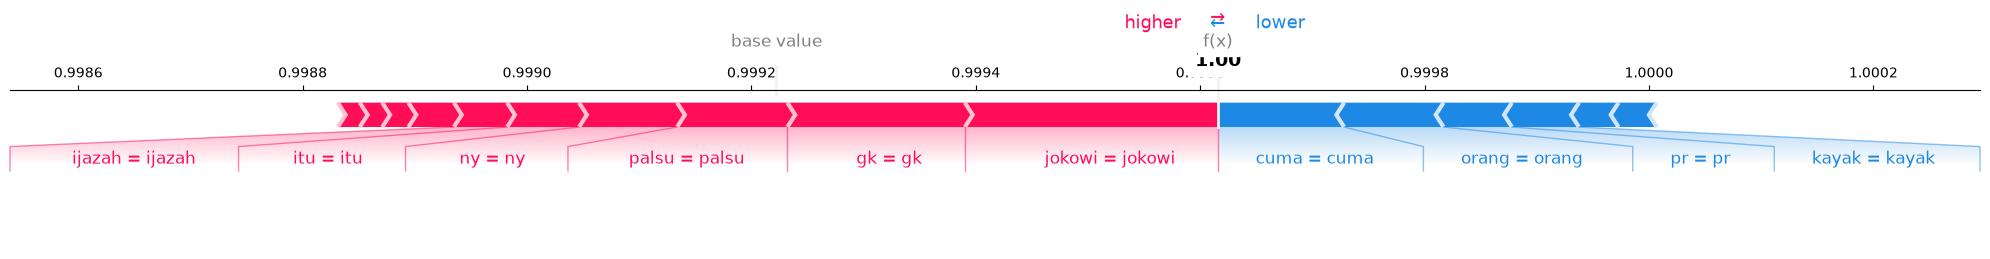

In [44]:
shap.plots.force(
    selected_value[0, :, 0],
    matplotlib=True,
    show=False
)

plt.tight_layout()

plt.savefig(
    "../output/shap_force_non_promosi.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
token_index = {
    token: i
    for i, token in enumerate(top_tokens)
}

shap_matrix = np.zeros(
    (len(values), len(top_tokens))
)

for i, sample in enumerate(values):

    tokens = [
        str(token).strip()
        for token in sample.data
    ]

    scores = sample.values[:, 1]

    for token, score in zip(tokens, scores):

        if token in token_index:

            shap_matrix[
                i,
                token_index[token]
            ] += score

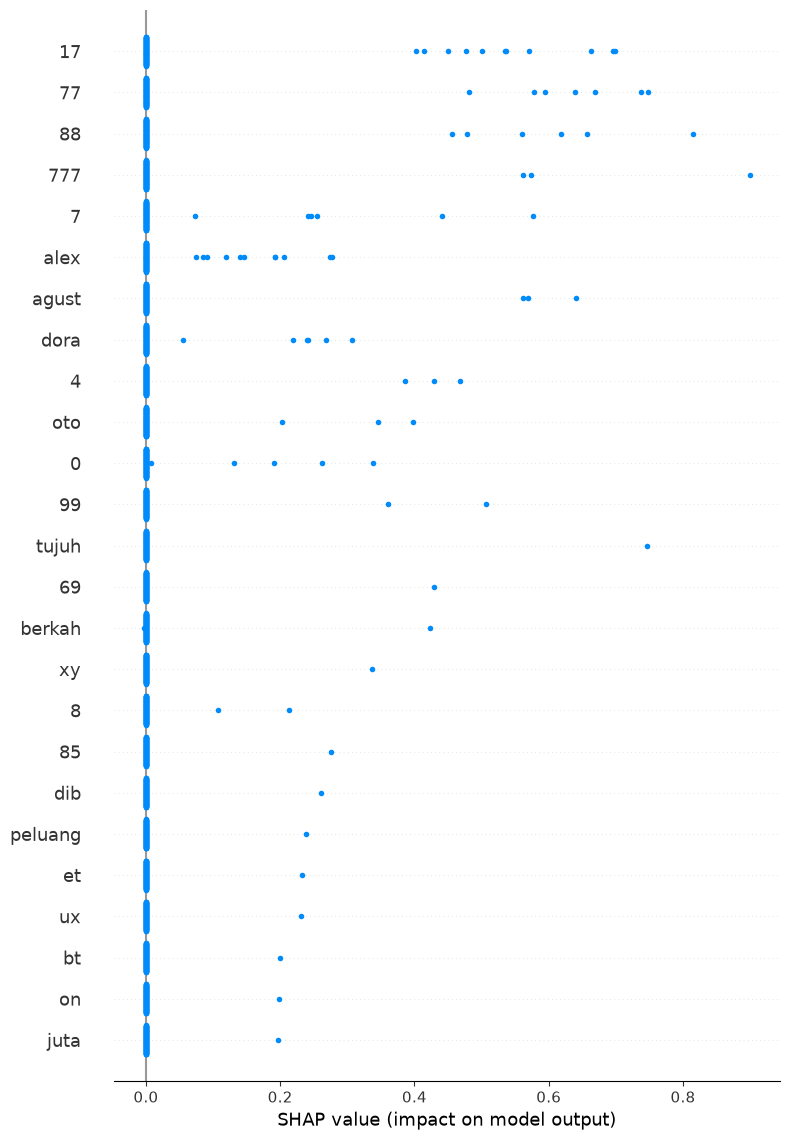

Summary plot berhasil disimpan.


In [26]:
plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_matrix,
    feature_names=top_tokens,
    max_display=25,
    show=False
)

plt.tight_layout()

plt.savefig(
    "../output/shap_summary_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Summary plot berhasil disimpan.")